# Introduction

The purpose of this project is to examine how demographic, parental, and religious factors influence youth drug use behavior. Understanding the drivers of substance use among youth is crucial for identifying at-risk groups and informing prevention strategies. 

In this analysis, we use a dataset containing survey responses from youths, which includes information on their background characteristics, family orientation, youth experiences and religiosity. Our research will focus on three research questions.To explore these relationships, we apply tree-based machine learning methods, including decision trees, bagging, boosting, and random forest, to capture both simple and complex patterns in the data. The results provide insight into which factors are most strongly associated with youth drug use and how these relationships vary across different modeling approaches.

 ### Research Question
 How do demographics, parental influence, and religiosity predict youth drug and marijuana use behavior, specifically:
1. Whether a youth has ever used any drug (binary classification - Used/Never Used)
2. The frequency of marijuana use in the past month (multi-class classification)?
3. The number of days per year a youth has used marijuana (regression)?


#### Import the required Libraries & Datasets
To import the required libraries


In [166]:
library(dplyr)
library(ggplot2)
library(tree)

To import the required Youth data file

In [167]:
download.file(
  "https://raw.githubusercontent.com/mendible/5322/main/Homework%201/youth_data.Rdata",
  "youth_data.RData",
  mode = "wb"
)

file.exists("youth_data.RData")

# Load the RData file
load("youth_data.RData")  # contains df
head(df)
glimpse(df)
str(df)


[1] TRUE

,IRALCFY,IRMJFY,IRCIGFM,IRSMKLSS30N,IRALCFM,IRMJFM,IRCIGAGE,IRSMKLSSTRY,IRALCAGE,IRMJAGE,⋯,EDUSCHLGO,EDUSCHGRD2,EDUSKPCOM,IMOTHER,IFATHER,INCOME,GOVTPROG,POVERTY3,PDEN10,COUTYP4
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<fct>,<ord>,<dbl>,<fct>,<fct>,<ord>,<fct>,<ord>,<fct>,<fct>
1,991,991,91,91,91,91,991,991,991,991,⋯,1,3,0,1,1,2,2,1,2,2
2,991,60,91,91,91,2,991,991,991,14,⋯,1,6,0,1,1,2,2,1,2,2
3,1,991,91,91,93,91,991,991,11,991,⋯,1,2,1,1,1,4,2,3,1,1
4,991,991,91,91,91,91,991,991,991,991,⋯,1,2,0,1,1,3,2,2,1,1
5,991,991,91,91,91,91,991,991,991,991,⋯,1,5,0,1,1,4,2,3,2,2
6,991,991,91,91,91,91,991,991,991,991,⋯,2,99,99,2,1,3,2,3,1,1


Rows: 10,561
Columns: 79
$ IRALCFY     <dbl> 991, 991, 1, 991, 991, 991, 991, 993, 991, 991, 991, 991, …
$ IRMJFY      <dbl> 991, 60, 991, 991, 991, 991, 991, 991, 991, 991, 10, 991, …
$ IRCIGFM     <dbl> 91, 91, 91, 91, 91, 91, 91, 91, 91, 91, 20, 91, 91, 91, 91…
$ IRSMKLSS30N <dbl> 91, 91, 91, 91, 91, 91, 91, 91, 91, 91, 91, 91, 1, 91, 91,…
$ IRALCFM     <dbl> 91, 91, 93, 91, 91, 91, 91, 93, 91, 91, 91, 91, 93, 91, 91…
$ IRMJFM      <dbl> 91, 2, 91, 91, 91, 91, 91, 91, 91, 91, 5, 91, 91, 91, 91, …
$ IRCIGAGE    <dbl> 991, 991, 991, 991, 991, 991, 991, 991, 991, 991, 17, 991,…
$ IRSMKLSSTRY <dbl> 991, 991, 991, 991, 991, 991, 991, 991, 991, 991, 991, 991…
$ IRALCAGE    <dbl> 991, 991, 11, 991, 991, 991, 991, 12, 991, 991, 991, 991, …
$ IRMJAGE     <dbl> 991, 14, 991, 991, 991, 991, 991, 991, 991, 991, 17, 991, …
$ MRJFLAG     <fct> 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0…
$ ALCFLAG     <fct> 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0…
$ TOBFLAG     <

### Data Preprocessing


In this section, we transform the dataset by cleaning invalid entries, recoding variables into meaningful categories, and constructing new features that capture key behaviors of interest. These steps—commonly referred to as data preprocessing and feature engineering—allow us to convert the original dataset into a structured form appropriate for classification, regression, and exploratory analysis.

In [168]:
youth_data_df <- df %>%
  mutate(
    # BINARY: ever used any drug (alcohol, marijuana, or tobacco)
    # ALCFLAG, MRJFLAG, TOBFLAG are already clean 0/1 flags in dataset
    if_drug_usage = factor(
      ifelse(ALCFLAG == 1 | MRJFLAG == 1 | TOBFLAG == 1, 1, 0),
      levels = c(0, 1),
      labels = c("Never Used", "Used")
    ),
    
    # MULTI-CLASS: marijuana frequency past month (already coded 1-5)
    # 1=1-2 days, 2=3-5 days, 3=6-19 days, 4=20-30 days, 5=non-user
    MRJ_NUM_DAYS = factor(
      MRJMDAYS,
      levels = c(1, 2, 3, 4, 5),
      labels = c("1-2 days", "3-5 days", "6-19 days", "20-30 days", "Non-user")
    ),
    
    # REGRESSION: days of marijuana use past year (IRMJFY)
    # Range for Marijuana Frequency Past Year (IRMJFY) is 1 - 365.
    # Regression requires real numbers to make meaningful predictions.
    # 991 and 993 are NOT within the valid range of 1-365.
    # They are special survey codes meaning:
    #   991 = Never used marijuana (lifetime non-user)
    #   993 = Did not use marijuana in the past year
    # Keeping them would corrupt the model by making it think someone
    # used marijuana 991 or 993 days in a year, which is impossible
    # since a year only has 365 days.
    # Therefore we replace 991 and 993 with NA so that
    # na.omit() can remove them, leaving only real day counts.
    marj_days_in_a_year = ifelse(IRMJFY %in% c(991, 993), NA, IRMJFY),
    
   
    # In order to ensure that when plots are created, we can get 
    # labels that indicate what is what, we add labels to variables

    
    # Race/Ethnicity
    # 1 = NonHisp White
    # 2 = NonHisp Black/African American
    # 3 = Native American/AK Native
    # 4 = NonHisp Native HI/Other Pacific Islander
    # 5 = NonHisp Asian
    # 6 = NonHisp More than one race
    # 7 = Hispanic
    NEWRACE2 = factor(NEWRACE2,
                      levels = c(1, 2, 3, 4, 5, 6, 7),
                      labels = c("NonHisp White",
                                 "NonHisp Black/Afr American",
                                 "Native American/AK Native",
                                 "NonHisp Native HI/Pacific Isl",
                                 "NonHisp Asian",
                                 "NonHisp More than one race",
                                 "Hispanic")),
    
    # Total family income (Imputed)
    # 1 = Less than $20,000
    # 2 = $20,000 - $49,999
    # 3 = $50,000 - $74,999
    # 4 = $75,000 or More
    INCOME = factor(INCOME,
                    levels = c(1, 2, 3, 4),
                    labels = c("Less than $20,000",
                               "$20,000 - $49,999",
                               "$50,000 - $74,999",
                               "$75,000 or More")),
    
    # Poverty level
    # 1 = Living in Poverty
    # 2 = Income Up to 2X Federal Poverty Threshold
    # 3 = Income More than 2X Federal Poverty Threshold
    POVERTY3 = factor(POVERTY3,
                      levels = c(1, 2, 3),
                      labels = c("Living in Poverty",
                                 "Up to 2X Fed Pov Threshold",
                                 "More than 2X Fed Pov Threshold")),
    
   
    
    # Parent limits time out on school night in past year
   # 1 = Always/Sometimes
    # 2 = Seldom/Never
    PARLMTSN = factor(PARLMTSN,
                      levels = c(1, 2),
                      labels = c("Yes", "No")),
    
    # Parent limits TV time
    # 1 = Always/Sometimes
    # 2 = Seldom/Never
    PRLMTTV2 = factor(PRLMTTV2,
                      levels = c(1, 2),
                      labels = c("Always/Sometimes", "Seldom/Never")),
    
    # Parent said marijuana use is wrong
    # 1 = Strongly Disapprove
    # 2 = Somewhat Disapprove or Neither
    PRMJEVR2 = factor(PRMJEVR2,
                      levels = c(1, 2),
                      labels = c("Strongly Disapprove", "Somewhat Disapprove or Neither")),
    
    # Talked with parent about dangers of tobacco/alcohol/drugs
    # 1 = Yes
    # 2 = No
    PRTALK3 = factor(PRTALK3,
                     levels = c(1, 2),
                     labels = c("Yes", "No")),
    

    
    # Number of times attended religious service in past year
    # 1 = 25 or more times
    # 2 = Less than 25 times
    RLGATTD = factor(RLGATTD,
                     levels = c(1, 2),
                     labels = c("25 or More", "Less than 25")),
    
    # Religious beliefs very important in life
    # 1 = Agree/Strongly Agree
    # 2 = Disagree/Strongly Disagree
    RLGIMPT = factor(RLGIMPT,
                     levels = c(1, 2),
                     labels = c("Agree/Strongly Agree",
                                "Disagree/Strongly Disagree")),
    
    # Religion influences decisions
    # 1 = Agree/Strongly Agree
    # 2 = Disagree/Strongly Disagree
    RLGDCSN = factor(RLGDCSN,
                     levels = c(1, 2),
                     labels = c("Agree/Strongly Agree",
                                "Disagree/Strongly Disagree")),
    
    # Friends share religious beliefs
    # 1 = Agree/Strongly Agree
    # 2 = Disagree/Strongly Disagree
    RLGFRND = factor(RLGFRND,
                     levels = c(1, 2),
                     labels = c("Agree/Strongly Agree",
                                "Disagree/Strongly Disagree"))
  )

To provide human reable variable names

In [169]:
youth_data_df <- youth_data_df %>%
  rename(
    Drug_Use = if_drug_usage,
    Marijuana_Use_Frequency = MRJ_NUM_DAYS,
    Marijuana_Days_Per_Year = marj_days_in_a_year,
    
    Race = NEWRACE2,
    Family_Income = INCOME,
    Poverty_Level = POVERTY3,
    
    Parent_Limits_School_Nights = PARLMTSN,
    Parent_Limits_TV = PRLMTTV2,
    Parent_Disapproval_Marijuana = PRMJEVR2,
    Parent_Drug_Talk = PRTALK3,
    
    Religious_Attendance = RLGATTD,
    Religion_Important = RLGIMPT,
    Religion_Influences_Decisions = RLGDCSN,
    Friends_Share_Religion = RLGFRND
  )

To filter the columns of interest

In [170]:
#filter predictors of primary interest
predictor_columns <- c(
  
  # Demographics
  "Race",   # Race/Ethnicity (1=NonHisp White, 2=NonHisp Black/Afr American,
                #  3=Native American/AK Native, 4=NonHisp Native HI/Pacific Isl,
                #  5=NonHisp Asian, 6=NonHisp More than one race, 7=Hispanic)
  
  "Family_Income",     # Total family income (1=Less than $20,000, 2=$20,000-$49,999,
                #  3=$50,000-$74,999, 4=$75,000 or More)
  
  "Poverty_Level",   # Poverty level (1=Living in Poverty, 
                #  2=Income Up to 2X Fed Pov Thresh,
                #  3=Income More than 2X Fed Pov Thresh)
  
  # Parental Influence
  "Parent_Limits_School_Nights",   # Parent limits screen time (1=Yes, 2=No)
  "Parent_Limits_TV",   # Parent limits TV time (1=Yes, 2=No)
  "Parent_Disapproval_Marijuana",   # Parent said marijuana use is wrong (1=Yes, 2=No)
  "Parent_Drug_Talk",    # Talked with parent about dangers of tobacco/alcohol/drugs
                #  (1=Yes, 2=No)
  
  # Religiosity
  "Religious_Attendance",    # Times attended religious service in past year
                #  (1=25 or More, 2=Less than 25)
  "Religion_Important",    # Religious beliefs very important in life
                #  (1=Agree/Strongly Agree, 2=Disagree/Strongly Disagree)
  "Religion_Influences_Decisions",    # Religion influences decisions
                #  (1=Agree/Strongly Agree, 2=Disagree/Strongly Disagree)
  "Friends_Share_Religion"     # Friends share religious beliefs
                #  (1=Agree/Strongly Agree, 2=Disagree/Strongly Disagree)
)


### Create model datasets:

To prepare datasets for the three types of models, we combine the response variables of interest with the selected predictor variables. For the binary classification model, we merge drug usage status with the key predictors. For the multiclass classification model, we focus on the frequency of marijuana use in the past month, combining this variable with the other relevant predictors. For the regression model, our target is the number of days a youth uses marijuana in a month, so we pair this response with the chosen predictor variables.

In [171]:
# Binary dataset

df.binary <- youth_data_df %>%
  select(Drug_Use, all_of(predictor_columns)) %>%
  na.omit()

#create dataset that will be used for multiclass classification

df.multiclass <- youth_data_df %>%
  select(Marijuana_Use_Frequency, all_of(predictor_columns)) %>%
  na.omit()

# Dataset for regression including marijuana users only

df.regression <- youth_data_df %>%
  filter(!is.na(Marijuana_Days_Per_Year)) %>% #ensure that there are no null values
  select(Marijuana_Days_Per_Year, all_of(predictor_columns)) %>%
  na.omit()

In [172]:
head(df.binary)

,Drug_Use,Race,Family_Income,Poverty_Level,Parent_Limits_School_Nights,Parent_Limits_TV,Parent_Disapproval_Marijuana,Parent_Drug_Talk,Religious_Attendance,Religion_Important,Religion_Influences_Decisions,Friends_Share_Religion
,<fct>,<fct>,<ord>,<ord>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>
1,Never Used,Hispanic,"$20,000 - $49,999",Living in Poverty,Yes,Seldom/Never,Strongly Disapprove,Yes,Less than 25,Agree/Strongly Agree,Agree/Strongly Agree,Agree/Strongly Agree
2,Used,NonHisp White,"$20,000 - $49,999",Living in Poverty,Yes,Seldom/Never,Somewhat Disapprove or Neither,Yes,Less than 25,Disagree/Strongly Disagree,Disagree/Strongly Disagree,Disagree/Strongly Disagree
3,Used,NonHisp More than one race,"$75,000 or More",More than 2X Fed Pov Threshold,Yes,Always/Sometimes,Strongly Disapprove,Yes,Less than 25,Agree/Strongly Agree,Agree/Strongly Agree,Disagree/Strongly Disagree
4,Never Used,Hispanic,"$50,000 - $74,999",Up to 2X Fed Pov Threshold,No,Seldom/Never,Strongly Disapprove,No,Less than 25,Agree/Strongly Agree,Agree/Strongly Agree,Disagree/Strongly Disagree
5,Never Used,NonHisp White,"$75,000 or More",More than 2X Fed Pov Threshold,No,Seldom/Never,Somewhat Disapprove or Neither,No,Less than 25,Disagree/Strongly Disagree,Disagree/Strongly Disagree,Disagree/Strongly Disagree
6,Never Used,Hispanic,"$50,000 - $74,999",More than 2X Fed Pov Threshold,Yes,Always/Sometimes,Strongly Disapprove,Yes,Less than 25,Agree/Strongly Agree,Agree/Strongly Agree,Disagree/Strongly Disagree


To check for missing values

In [173]:
colSums(is.na(df.binary))

Drug_Use                          Race 
                            0                             0 
                Family_Income                 Poverty_Level 
                            0                             0 
  Parent_Limits_School_Nights              Parent_Limits_TV 
                            0                             0 
 Parent_Disapproval_Marijuana              Parent_Drug_Talk 
                            0                             0 
         Religious_Attendance            Religion_Important 
                            0                             0 
Religion_Influences_Decisions        Friends_Share_Religion 
                            0                             0

In [174]:
colSums(is.na(df.multiclass))

Marijuana_Use_Frequency                          Race 
                            0                             0 
                Family_Income                 Poverty_Level 
                            0                             0 
  Parent_Limits_School_Nights              Parent_Limits_TV 
                            0                             0 
 Parent_Disapproval_Marijuana              Parent_Drug_Talk 
                            0                             0 
         Religious_Attendance            Religion_Important 
                            0                             0 
Religion_Influences_Decisions        Friends_Share_Religion 
                            0                             0

In [175]:
colSums(is.na(df.regression))

Marijuana_Days_Per_Year                          Race 
                            0                             0 
                Family_Income                 Poverty_Level 
                            0                             0 
  Parent_Limits_School_Nights              Parent_Limits_TV 
                            0                             0 
 Parent_Disapproval_Marijuana              Parent_Drug_Talk 
                            0                             0 
         Religious_Attendance            Religion_Important 
                            0                             0 
Religion_Influences_Decisions        Friends_Share_Religion 
                            0                             0

## Modelling

#### Train/Test Split

Split dataset into training and test set for **binary classification** dataset

In [176]:
set.seed(1)
train_index <- sample(nrow(df.binary), 0.7 * nrow(df.binary))
train_bin_class <- df.binary[train_index, ]
test_bin_class <- df.binary[-train_index,]


Split dataset into training and test set for **multi class** dataset

In [177]:
set.seed(1)
train_index_multi <- sample(nrow(df.multiclass), 0.7 * nrow(df.multiclass))
train_multi_class <- df.multiclass[train_index_multi, ]
test_multi_class <- df.multiclass[-train_index_multi, ]

Split dataset into training and test set for **regression** dataset

In [178]:
set.seed(1)
train_index_reg <- sample(nrow(df.regression), 0.7 * nrow(df.regression))
train_reg_class <- df.regression[train_index_reg, ]
test_reg_class  <- df.regression[-train_index_reg, ]

## Binary Classification Problem

Using Tree Based Methods - Decision Tree , Bagging & RandomForest

#### Applying Decision Tree to Binary classification

import library

In [179]:
library(tree)


In [180]:
library(rpart)
library(rpart.plot)
library(ggplot2)

#### Fit Decision Tree

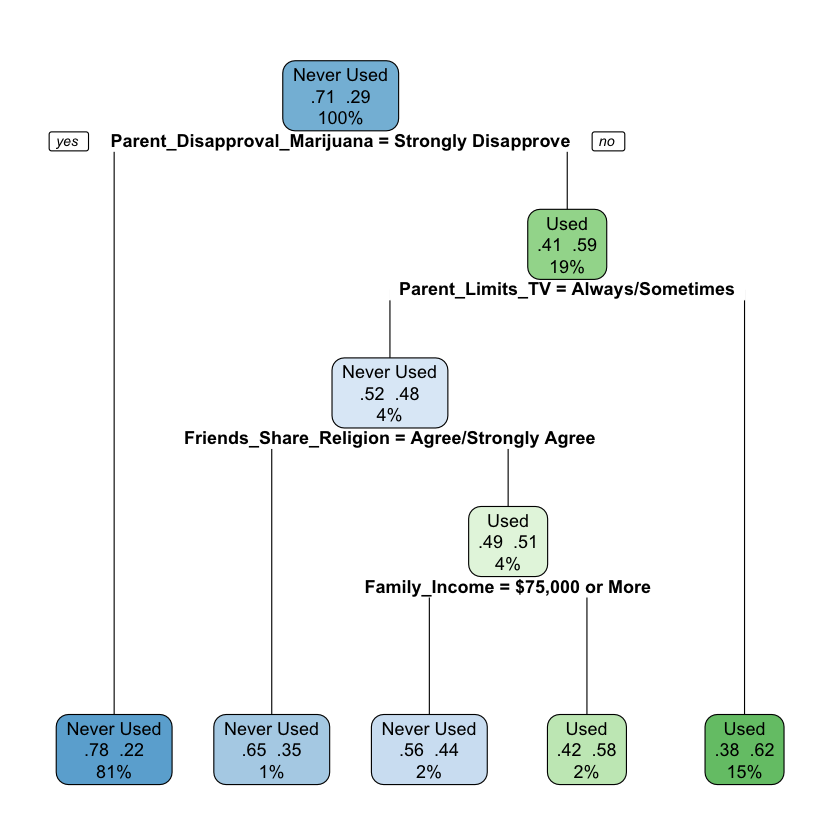

In [181]:
set.seed(1)
tree_bin_class <- rpart(
  Drug_Use ~ ., 
  data = train_bin_class, 
  method = "class",
  control = rpart.control(cp = 0.001, #complexity parameter
  maxdepth = 4, #set tree depth
  minsplit = 20, 
  minbucket = 10) #set min # of observations in leaf nodes
)

#quartz(width = 12, height = 8)  
rpart.plot(tree_bin_class, type = 2, extra = 104, cex = 0.9, fallen.leaves = TRUE)



The decision tree model examines the relationship between certain demographic, religiosity, and parental factors and their influence on youth drug use. The most important variable that has been identified is "PRMJEVR2 - parental disapproval of marijuana use", which forms the first and most significant split in the tree. Individuals whose parents strongly disapprove of marijuana use are much more likely to have never used drugs, with 78% reporting no drug use. They also represent the majority in this given sample.
On the other hand, individuals whose parents do not strongly disapprove are more likely to have used drugs, with approximately 59% reporting drug use. However, we see that this group is smaller, comprising only about 19% of the dataset.
Going into the further splits, PRLMTTV2 - parent limiting TV time - shows that among individuals whose parents do not strongly disapprove, those whose parents limit TV time (Always/Sometimes) can be further divided into smaller subgroups. Additional variables such as RLGFRND (friends sharing religious beliefs) and income levels help refine these groups, with some subgroups showing a higher likelihood of drug use (around 51% to 62%). However, these groups represent a relatively small proportion of the dataset, indicating that their overall impact is limited.

To make prediction

In [182]:
pred_tree_bin_class <- predict(tree_bin_class, test_bin_class, type = "class")

# create confusion matrix
table(Predicted = pred_tree_bin_class,
      Actual = test_bin_class$Drug_Use)

            Actual
Predicted    Never Used Used
  Never Used       1863  561
  Used              190  281

##### Evaluate model

To evaluate the model, we compute error rate

In [183]:
accuracy <- mean(pred_tree_bin_class == test_bin_class$Drug_Use)
error_rate <- 1 - accuracy
error_rate

[1] 0.2594128

The decision tree achieved a misclassification error rate of approximately 0.2594 on the test dataset, meaning that about 25.94% of observations were incorrectly classified by the model. This corresponds to a moderate level of predictive performance, although there is still room for improvement. 

In order to potentially enhance model performance and reduce overfitting, we next consider pruning the tree to identify a simpler structure that generalizes better to unseen data.

##### Pruning Tree

To perform pruning, cross-validation is first used to determine the optimal level of tree complexity. This helps us to identify the tree size that will minimize prediction error on unseen data hence allowing us to obtaina simpler and more generalized model. 



**NOTE**: When using rpart, cross validation is alreadly built into the model so to obtain the needed parameters, we can simply use printcp() function. 

In [184]:
set.seed(1)
#cv_tree_bin_class <- cv.tree(tree_bin_class, FUN = prune.misclass)

printcp(tree_bin_class)


Classification tree:
rpart(formula = Drug_Use ~ ., data = train_bin_class, method = "class", 
    control = rpart.control(cp = 0.001, maxdepth = 4, minsplit = 20, 
        minbucket = 10))

Variables actually used in tree construction:
[1] Family_Income                Friends_Share_Religion      
[3] Parent_Disapproval_Marijuana Parent_Limits_TV            

Root node error: 1943/6755 = 0.28764

n= 6755 

         CP nsplit rel error  xerror     xstd
1 0.1204323      0   1.00000 1.00000 0.019148
2 0.0077200      1   0.87957 0.87957 0.018389
3 0.0048893      2   0.87185 0.88214 0.018407
4 0.0010000      4   0.86207 0.87802 0.018378


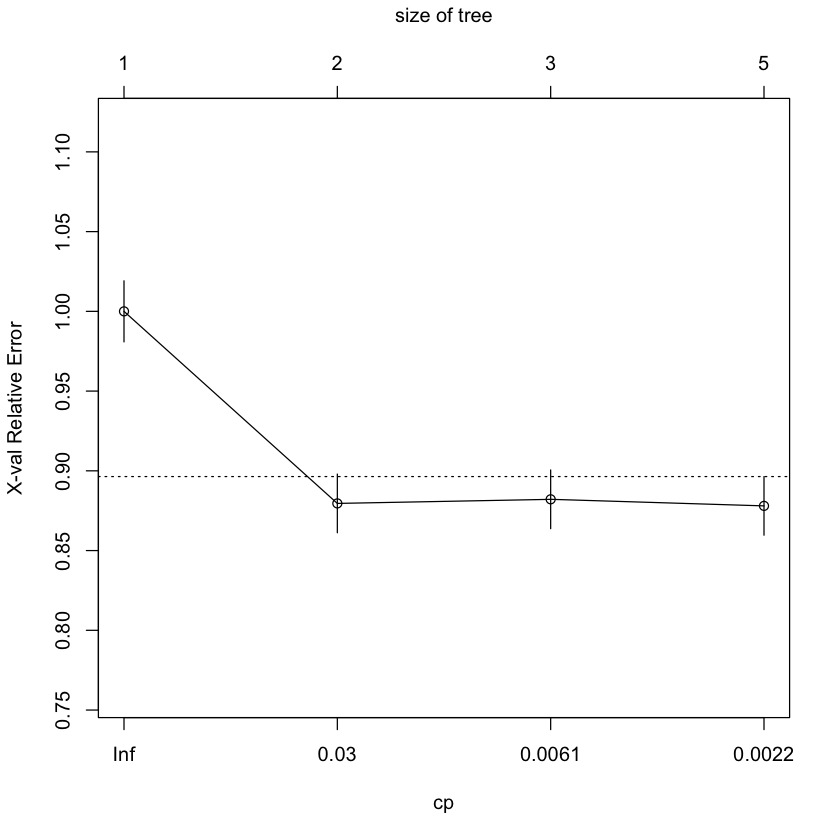

In [185]:
plotcp(tree_bin_class)

To obtain the cp with the minimum error:

In [186]:
best <- tree_bin_class$cptable[
  which.min(tree_bin_class$cptable[, "xerror"]),
  "CP"
]
best

[1] 0.001

To prune the tree:

In [187]:
pruned_tree_bin <- prune(tree_bin_class, cp = best)

To plot the pruned tree:

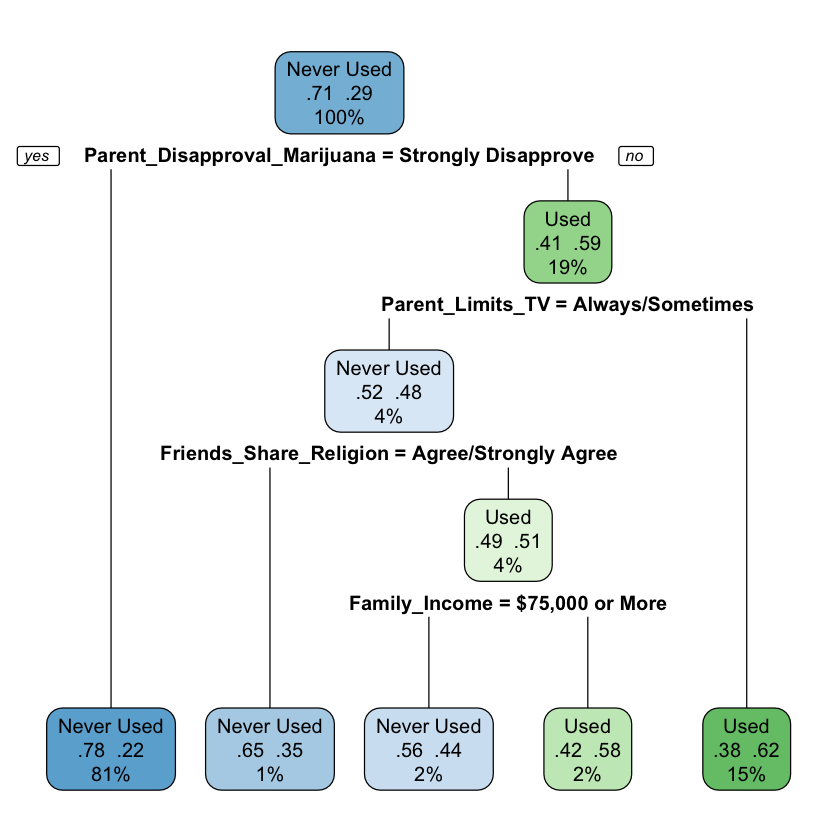

In [188]:
rpart.plot(pruned_tree_bin, type = 2, extra = 104)

To perform prediction using the pruned tree

In [189]:
pruned_pred_tree_bin_class <- predict(
  pruned_tree_bin, 
  test_bin_class, 
  type = "class"
)

# create confusion matrix
table(
  Predicted = pruned_pred_tree_bin_class,
  Actual = test_bin_class$Drug_Use
)

            Actual
Predicted    Never Used Used
  Never Used       1863  561
  Used              190  281

In [190]:
accuracy.pruned <- mean(pruned_pred_tree_bin_class == test_bin_class$Drug_Use)
error_rate.pruned <- 1 - accuracy.pruned
error_rate.pruned

[1] 0.2594128

#### Using Decision Tree with simple function

We can also use the simple tree() function to obtain our results

In [220]:
tree_model <- tree(
  Drug_Use ~ .,
  data = train_bin_class
)

In [224]:
# tree_model_2 <- tree(
#   Drug_Use ~ .,
#   data = train_bin_class,
#   control = tree.control(nobs = nrow(train_bin_class), mindev = 0.01)
# )

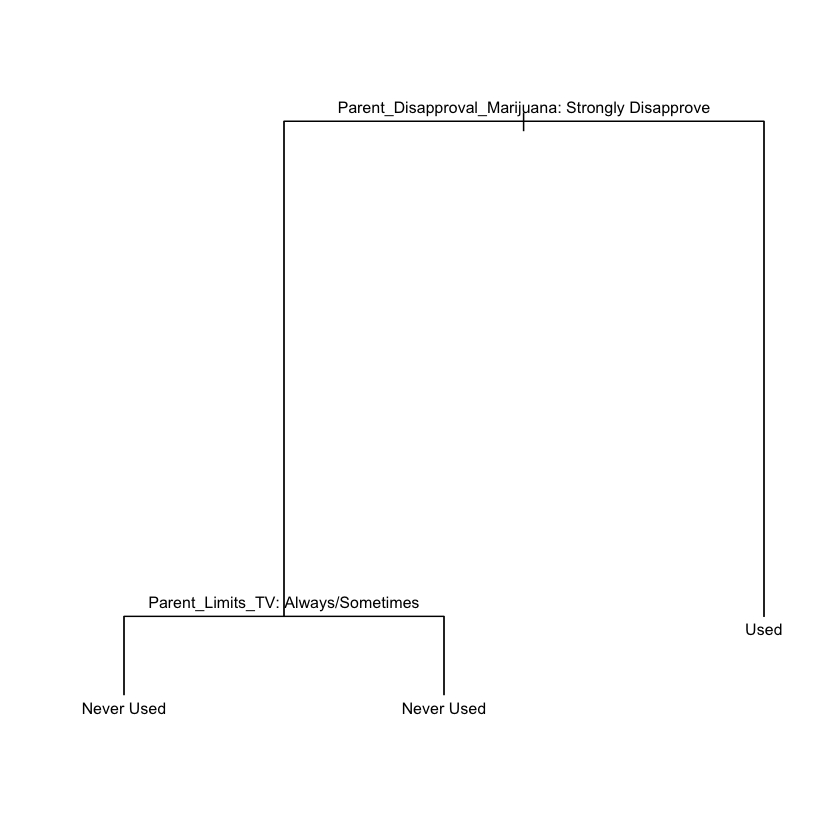

In [192]:
plot(tree_model)
text(tree_model, pretty = 0, cex = 0.8)



For the terminal node predicting “Never Used,” the decision tree shows that parental disapproval of marijuana is the most important determining factor. As we follow the path toward this outcome, even though the model includes a split on whether parents limit TV time, this variable does not meaningfully change the prediction—both branches still lead to “Never Used.” This indicates that once strong parental disapproval is present, additional household rules like TV limits have little impact on the outcome. In contrast, on the opposite side of the tree, when parents do not strongly disapprove of marijuana use, the model predicts that the youth is more likely to have used marijuana, highlighting the central role of parental attitudes in shaping this behavior.


In [193]:
tree_pred <- predict(tree_model, test_bin_class, type = "class")
tree_accuracy<- mean(tree_pred == test_bin_class$Drug_Use)

In [194]:
tree.error <- 1 - tree_accuracy
tree.error

[1] 0.262867

Pruning could help us improve the model, but first we need to use cross-validation to find the optimal tree size (or complexity parameter) that minimizes misclassification error.

In [195]:
set.seed(1)

cv_tree <- cv.tree(tree_model, FUN = prune.misclass)
names(cv_tree)

[1] "size"   "dev"    "k"      "method"

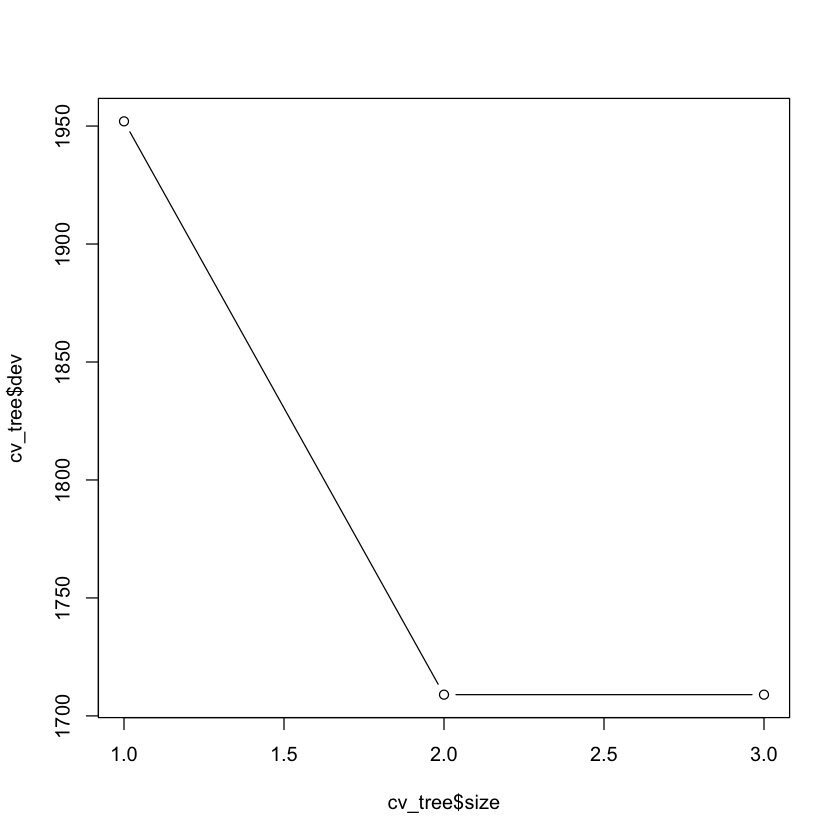

In [196]:
plot(cv_tree$size,cv_tree$dev, type = "b")

Since the optimal tree size of 2 has been obtained. We are to prune the tree. 


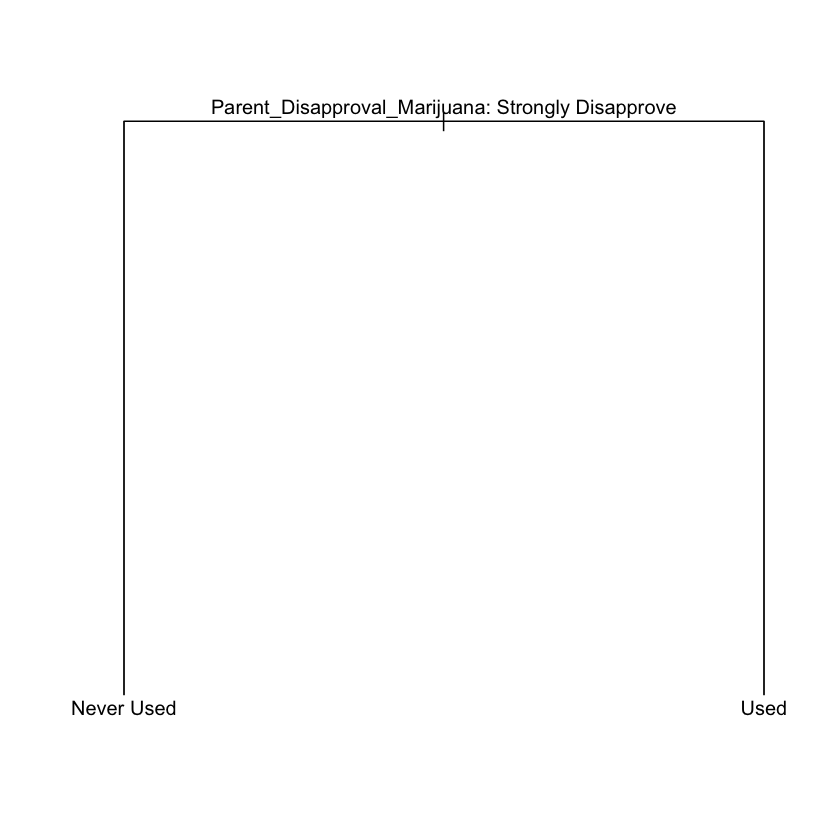

In [197]:
pruned_model <- prune.misclass(tree_model, best = 2)
plot(pruned_model)
text(pruned_model, pretty=0)

To perform prediction with the pruned tree

In [198]:
tree_pred <- predict(pruned_model,test_bin_class, type = "class" )
pruned.error<- mean(tree_pred != test_bin_class$Drug_Use)
pruned.error

[1] 0.262867

The pruned tree achieves an error rate of approximately 0.263, which is the same as the unpruned tree. This highlights that pruning did not reduce predictive accuracy in our case, but it improves model simplicity and interpretability by reducing unnecessary splits.

#### Applying RandomForest to Binary classification

While decision trees are easy to interpret, they do have a drawback, which is, they are prone to overfitting as small changes in training data can lead to a different tree structure. An Ensemble approach - Random Forest- addresses this limitation by constructing a large number of decision trees bootstrapped samples of the training data & a random subset of predictor variables at each split. The final output is obtained by aggregating the output from all the trees(i.e. majority vote for classification or averaging for regression). This ensemble method helps redice the variance and improves generalization to unseen data. 

Import library

In [199]:
library(randomForest)

To fit model Using Random Forest Approach

In [200]:
set.seed(1) #for reproducibility

#compute number of predictors(p) 
p <- ncol(train_bin_class) -1

#fit the model
#Recall Random Forest() uses p/3 when build rf for regression and sqrt(p) when building rf for classification
rf.bin_class <- randomForest(Drug_Use~., data = train_bin_class,mtry = floor(sqrt(p)), importance = TRUE)

Note: Recall Random Forest() uses p/3 when build rf for regression and sqrt(p) when building rf for classification

To make prediction and calculate error rate

In [201]:
pred.rf.bin_class <- predict(rf.bin_class,newdata = test_bin_class)
pred.rf.error<- mean(pred.rf.bin_class != test_bin_class$Drug_Use)
pred.rf.error

[1] 0.2666667

For the binary classification using both single decision tree and the Random Forest Model, the Random Forest model produced a slightly higher error rate of 26.63%. Although Random Forest is generally expected to outperform a single decision tree due to variance reduction through averaging multiple trees, in this case the performance difference is minimal. This indicates that the underlying pattern of the data may be captured by a simple tree structure and using a more complex model does not improve predictive accuracy. 


To view the importance of each variable

In [202]:
importance(rf.bin_class)

,Never Used,Used,MeanDecreaseAccuracy,MeanDecreaseGini
Race,20.506247,-2.1241438,16.837326,128.98041
Family_Income,32.000768,-17.7192255,30.773587,70.79448
Poverty_Level,27.127154,-11.1661741,29.076695,47.50523
Parent_Limits_School_Nights,10.891281,-7.9422235,4.326210,39.01522
Parent_Limits_TV,8.376756,26.1197246,25.235182,63.85135
Parent_Disapproval_Marijuana,84.057515,127.6858830,136.157689,263.33671
Parent_Drug_Talk,6.467723,0.8295653,5.603314,39.56518
Religious_Attendance,7.398596,10.9624619,15.010391,29.85189
Religion_Important,32.638920,-12.3810365,30.626754,32.80928
Religion_Influences_Decisions,42.150559,-13.7724730,42.386940,34.93150


**Note** :

- MeanDecreaseAccuracy determines how much accuracy will drop if the variable is removed.
- MeanDecreaseGini how well model improves node purity

The important predictors of drugs use include:
 - PRMJEVR2 - Parent's feeling about Marijuana ( 1- Strongly Disapprove,2- Somewhat Disapprove or Neither  )
 - RLGDCSN - Religious beliefs influence life decisions
- INCOME - Family Income
-RLGIMPT - religious beliefs very important in life
- POVERTY3 - Poverty Level

#### Applying Bagging to Binary classification

To train the model using Bagging ensemble method, we follow the same steps in the Rain Forest approach. The key  difference is that, in bagging, all predictors are considered at each split(i.e. mtry = p, where p is the total number of predictors), Random Forest only selects a portion of predictors at each split. 

In [203]:
set.seed(1) #for reproducibility

#compute number of predictors(p) 
p <- ncol(train_bin_class) -1

#fit the model
#Bagging consider all predictors in split
bag.bin_class <- randomForest(Drug_Use~., data = train_bin_class,mtry = p, importance = TRUE)

To make prediction

In [204]:
pred.bag.bin_class <- predict(bag.bin_class,newdata = test_bin_class)
pred.bag.error<- mean(pred.bag.bin_class != test_bin_class$Drug_Use)
pred.bag.error

[1] 0.2943005

The test error rate obtained 29.43% using Bagging is higher than the test error obtained using Random Forest and Decision Tree approach. 

## Evaluating each model

In [205]:
binary_class_compare<- data.frame(
    Model = c("Decision Tree", "Random Forest", "Bagging"),
    test_error = c(error_rate.pruned,pred.rf.error,pred.bag.error)
)
binary_class_compare

Model,test_error
<chr>,<dbl>
Decision Tree,0.2594128
Random Forest,0.2666667
Bagging,0.2943005


The decision tree model achieved the lowest test error (0.259), slightly outperforming both random forest (0.267) and bagging (0.294). This suggests that a relatively simple model might be more sufficient in capturing the main structure in the data. The lack of improvement from ensemble methods indicates that the relationship between predictors and drug use may be driven by a small number of strong variables, rather than complex interactions requiring more flexible models.

### Multi-Class Classification 

In this section, we answer focus on the question:
- The frequency of marijuana use in the past month (multi-class classification)?

##### Create Random Forest for Multi-Class Classification

To view how many unique values in our target column

In [206]:
unique(youth_data_df$MRJMDAYS)

[1] 5 1 2 3 4

In [207]:
library(randomForest) #import random Forest library

#fit the model
rf.multiclass <- randomForest(
  Marijuana_Use_Frequency~ .,
  data = train_multi_class,
  ntree = 500,
  importance = TRUE
)

Making prediction and Evaluating Performance

In [226]:
pred_rf <- predict(rf.multiclass, test_multi_class)

table(pred_rf, test_multi_class$Marijuana_Use_Frequency)

mean(pred_rf != test_multi_class$Marijuana_Use_Frequency)

            
pred_rf      1-2 days 3-5 days 6-19 days 20-30 days Non-user
  1-2 days          0        0         0          0        0
  3-5 days          0        0         0          0        0
  6-19 days         0        0         0          0        0
  20-30 days        0        0         0          0        0
  Non-user         48       47        62         55     2683

[1] 0.07322971

The confusion matrix reveals that the model achieves a high overall accuracy of 92.85%, but this performance is largely driven by the overwhelming dominance of the “Non-user” class. While the model correctly classifies most non-users (2683 instances), it performs poorly on the smaller, more meaningful user activity categories. In particular, it completely fails to identify the “1–2 days” group and shows very limited success in predicting the “3–5 days,” “6–19 days,” and “20–30 days” categories, with only a few correct classifications in each. A significant number of actual users across all activity levels are misclassified as “Non-user,” indicating a strong bias toward the majority class. This suggests that despite the high accuracy, the model lacks effectiveness in distinguishing between different levels of user engagement, likely due to severe class imbalance in the dataset.

To obtain the variables that are most important

In [209]:
importance(rf.multiclass)

,1-2 days,3-5 days,6-19 days,20-30 days,Non-user,MeanDecreaseAccuracy,MeanDecreaseGini
Race,-3.1492630,3.99472140,-0.8562448,2.8240768,8.026393,8.554789,45.336751
Family_Income,-3.9707310,-4.91579508,-6.0259549,-7.4097035,26.402108,25.639631,32.207271
Poverty_Level,-7.9332164,-8.82954374,-3.0667850,-2.8644639,24.645938,24.651008,22.120882
Parent_Limits_School_Nights,0.1671475,0.09530216,-1.3133664,1.0892675,1.471769,1.546163,16.288780
Parent_Limits_TV,-0.2756080,-1.05387485,-3.9609666,6.7439512,4.405059,5.011519,11.316284
Parent_Disapproval_Marijuana,6.5701137,11.49127895,10.2986609,23.3624863,26.607012,32.088711,64.913742
Parent_Drug_Talk,-4.7931751,-1.08258636,1.7990944,0.8596338,4.966598,4.606580,17.601176
Religious_Attendance,1.9856463,-0.04313046,-6.0084891,4.3616937,8.241068,8.229363,8.907562
Religion_Important,-7.7456935,-5.27586810,-0.5293346,-3.6765434,25.989679,25.058837,14.057501
Religion_Influences_Decisions,-10.2505521,-8.61227253,-0.4321333,-10.6014926,37.141413,36.018558,13.335789


The Random Forest variable importance results show that PRMJEVR2 is the most influential predictor in the model, with the highest values for both Mean Decrease Accuracy and Mean Decrease Gini, indicating it plays a central role in distinguishing between marijuana usage activity groups. Other variables such as POVERTY3, INCOME, and RLGDCSN also contribute meaningfully to overall model performance, as removing them leads to notable reductions in accuracy. However, the importance values vary considerably across classes, with some predictors showing strong positive effects for certain groups while having weak or even negative effects for others. These negative values suggest that some variables may introduce noise or are less useful for predicting specific categories. Additionally, the dominance of the “Non-user” class likely amplifies the importance of variables that are effective at identifying this group, while reducing the apparent contribution of predictors relevant to smaller user categories. Overall, the results indicate that a few key variables drive most of the model’s predictive power, but their influence is not uniform across all classes.

## Regression Problem

### Building Regression Model - using Boosting

We use a regression model to answer the question we indicated above:
- The number of days per month a youth has used marijuana (regression)?

Import required library

In [210]:
library(gbm) # we need this package to be able to fit boosted regression trees

To view dataframe

In [211]:
head(train_reg_class)

,Marijuana_Days_Per_Year,Race,Family_Income,Poverty_Level,Parent_Limits_School_Nights,Parent_Limits_TV,Parent_Disapproval_Marijuana,Parent_Drug_Talk,Religious_Attendance,Religion_Important,Religion_Influences_Decisions,Friends_Share_Religion
,<dbl>,<fct>,<ord>,<ord>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>
1069,360,NonHisp White,"$50,000 - $74,999",Up to 2X Fed Pov Threshold,Yes,Always/Sometimes,Somewhat Disapprove or Neither,Yes,Less than 25,Disagree/Strongly Disagree,Disagree/Strongly Disagree,Disagree/Strongly Disagree
711,2,NonHisp White,"$75,000 or More",More than 2X Fed Pov Threshold,No,Seldom/Never,Strongly Disapprove,Yes,Less than 25,Disagree/Strongly Disagree,Disagree/Strongly Disagree,Disagree/Strongly Disagree
131,240,Hispanic,"Less than $20,000",Living in Poverty,Yes,Seldom/Never,Somewhat Disapprove or Neither,No,Less than 25,Disagree/Strongly Disagree,Disagree/Strongly Disagree,Disagree/Strongly Disagree
975,1,NonHisp White,"$75,000 or More",More than 2X Fed Pov Threshold,Yes,Always/Sometimes,Strongly Disapprove,Yes,Less than 25,Disagree/Strongly Disagree,Disagree/Strongly Disagree,Disagree/Strongly Disagree
493,3,NonHisp White,"$75,000 or More",More than 2X Fed Pov Threshold,Yes,Seldom/Never,Strongly Disapprove,Yes,Less than 25,Agree/Strongly Agree,Agree/Strongly Agree,Agree/Strongly Agree
311,155,Hispanic,"$20,000 - $49,999",Up to 2X Fed Pov Threshold,No,Seldom/Never,Somewhat Disapprove or Neither,No,Less than 25,Disagree/Strongly Disagree,Agree/Strongly Agree,Disagree/Strongly Disagree


The gbm() function requires a parameter known as shrinkage which determines how much each tree contributes to the model. We fit our model using multiple shrinkage values to identify the shrinkage value that minimized mean squared error. The model is then refit using the optimal shrinkage value to make final predictions.

In [212]:
set.seed(1) # for reproducibility


shrink_val <- c(0.001, 0.01, 0.02,0.05, 0.1, 0.2, 0.5)
# also create a numeric vector to store training MSE
mse.train <- numeric(length(shrink_val))
mse.test <-  numeric(length(shrink_val))

#loop allows us to try different shrinkage values 
for (i in seq_along(shrink_val)) {
  lam <- shrink_val[i]
  
  # fitting the model
  boost.reg_class <- gbm(
    Marijuana_Days_Per_Year ~ ., 
    data = train_reg_class, 
    distribution = "gaussian", 
    n.trees = 1000, 
    interaction.depth = 4, 
    shrinkage = lam,
    verbose = FALSE
  )
  
  # making predictions
  pred <- predict(boost.reg_class, test_reg_class, n.trees = 1000)
  
  # compute MSE
  mse_vals[i] <- mean((pred - test_reg_class$Marijuana_Days_Per_Year)^2)
}

#obtain the shrinkage value with least mse
best.reg <- shrink_val[which.min(mse_vals)]
best.reg #optimal shrinkage value

[1] 0.001

To refit the model using the best shrinkage

In [213]:
# Refit model using best shrinkage
refit.boost.reg_class <- gbm(
  Marijuana_Days_Per_Year ~ ., 
  data = train_reg_class, 
  distribution = "gaussian", 
  n.trees = 1000, 
  interaction.depth = 4, 
  shrinkage = best.reg,
  verbose = FALSE
)

# Make the final predictions
final_pred <- predict(refit.boost.reg_class, test_reg_class, n.trees = 1000)

# compute the MSE
final.mse.boost.reg <- mean((final_pred - test_reg_class$Marijuana_Days_Per_Year)^2)

final.mse.boost.reg

[1] 12633.02

### Building Regression Model - using RandomForest

In [214]:

#obtain the value for p
p <- ncol(train_reg_class)-1 
rf.reg <- randomForest(
    Marijuana_Days_Per_Year~.,
    data = train_reg_class,
    ntree = 1000,
    mtry = floor(p/3),
    importance = TRUE
    
    )

Make prediction and compute the MSE

In [215]:
pred.reg <- predict(rf.reg, test_reg_class)

#compute the MSE

mse.rf.reg <- mean((pred - test_reg_class$Marijuana_Days_Per_Year)^2)
mse.rf.reg


[1] 20647.35

#### Comparison for Regression models

In [216]:
reg_compare <- data.frame(
    Model = c("Random Forest (Regression)", "Boosting (GBM)"),
    MSE = c(mse.rf.reg, final.mse.boost.reg)
)
reg_compare

Model,MSE
<chr>,<dbl>
Random Forest (Regression),20647.35
Boosting (GBM),12633.02


Comparing the MSE obtained from both models for the Regression problem. The boosting model outperformed the random forest model with a substantially lower MSE (12633 compared to 20647).  This suggests that boosting better captures the nonlinear relationships in the data by sequentially improving weak learners, whereas random forest averages independent trees and may underfit more complex patterns in this dataset.

In [217]:
rmarkdown::convert_ipynb("homework1_varnames.ipynb")

# Conclusion

The class imbalance were identified and can be improved by adding class weights when fitting the model. 

## References

https://www.youtube.com/watch?v=uXIIk7suD6c